# A simple & small model for XOR

In [30]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
import numpy as np
# Using the following input training data (with more samples) for 3 different models
X = np.array([[0,0], [0,1], [1,0], [1,1]]) #
y = np.array([[0],   [1],   [1],   [0]]) # corresponding labels
Xt = np.array([[0,0.1], [0,1], [0.9,0], [1,1]]) # new unseen test data
yt = np.array([[0],     [1],   [1],     [0]])

model = Sequential([
    Input(shape=(2,)), # Use Input layer as the first layer
    Dense(2, activation='sigmoid'),
    Dense(1, activation='sigmoid') # sigmoid was also used in Evo search version
])

model.compile(
    loss='mse', # mse is also used in Evo search code for comparison
    optimizer=optimizers.SGD(learning_rate=0.1), # stochastic gradient decent
    #optimizer=optimizers.RMSprop(learning_rate=0.01),
    metrics=['binary_accuracy']
)
history = model.fit(X, y, batch_size=1, epochs=500, verbose=0)
loss = history.history['loss'][-1] # Get the final loss
acc = history.history['binary_accuracy'][-1] # Get the final accuracy

In [31]:
print("Train Loss: ", loss)
print("Train Accuracy: ", acc)

# Define hypothetical true labels for Xt to allow model.evaluate()
# Assuming Xt follows an XOR-like pattern for demonstration
yt = np.array([[0], [1], [1], [0]])

print(model.evaluate(Xt, yt, verbose=0))
print(model.predict(Xt, verbose=0).round() )

Train Loss:  0.24648410081863403
Train Accuracy:  0.5
[0.24282123148441315, 0.5]
[[1.]
 [1.]
 [0.]
 [0.]]


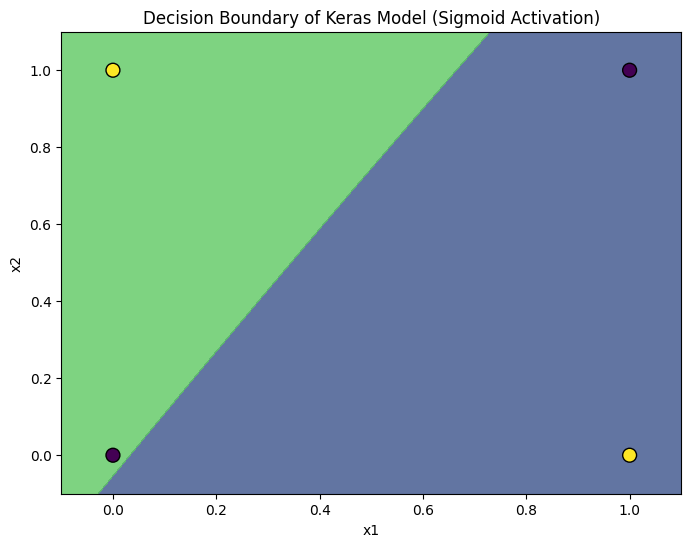

In [36]:
import matplotlib.pyplot as plt

# Define the range for the input features
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

# Create a meshgrid
h = 0.01  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict the output for each point in the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z = Z.reshape(xx.shape)

# Plot the decision boundary with two distinct colors
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='viridis', alpha=0.8) # Changed colormap to viridis

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis', edgecolors='k', s=100) # Increased marker size with s=100 and changed colormap to viridis
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundary of Keras Model (Sigmoid Activation)')
plt.show()